In [3]:
import pandas as pd
import matplotlib.pyplot as plt

cpu = pd.read_csv("../results/processed/cpu_results.csv")

cpu

/home/divya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,environment,threads,run,events_per_second
0,vm,4,1,3040.91
1,vm,4,10,3787.39
2,vm,4,2,3489.49
3,vm,4,3,3553.22
4,vm,4,4,3749.74
5,vm,4,5,3765.72
6,vm,4,6,4030.49
7,vm,4,7,3984.55
8,vm,4,8,4092.94
9,vm,4,9,3822.72


In [6]:
summary = cpu.groupby("environment")[
    "events_per_second"
].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

summary

,mean,median,min,max,std
environment,,,,,
container,4020.613,4041.505,3868.77,4132.76,100.638815
vm,3731.717,3776.555,3040.91,4092.94,309.889471


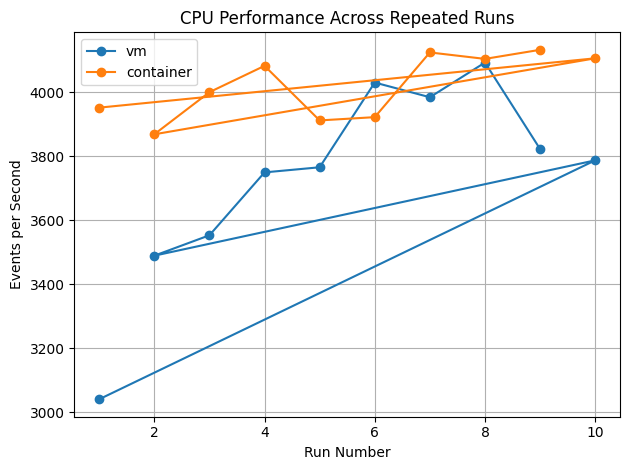

In [7]:
for environment in cpu["environment"].unique():
    data = cpu[cpu["environment"] == environment]

    plt.plot(
        data["run"],
        data["events_per_second"],
        marker="o",
        label=environment
    )

plt.xlabel("Run Number")
plt.ylabel("Events per Second")
plt.title("CPU Performance Across Repeated Runs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
memory = pd.read_csv(
    "../results/processed/memory_results.csv"
)

memory.groupby("environment")[
    "MiB_per_sec"
].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

,mean,median,min,max,std
environment,,,,,
container,29520.900,29681.830,25556.91,31859.53,1790.080818
vm,42692.741,42694.365,41049.78,44014.45,821.149267


In [9]:
disk = pd.read_csv(
    "../results/processed/disk_results.csv"
)

disk

,environment,workload,bandwidth,unit
0,vm,seq-read,887.0,MiB/s
1,vm,seq-write,1178.0,MiB/s
2,vm,random-read,20.7,MiB/s
3,vm,random-write,18.3,MiB/s
4,container,seq-read,811.0,MiB/s
5,container,seq-write,851.0,MiB/s
6,container,random-read,18.2,MiB/s
7,container,random-write,21.2,MiB/s


In [10]:
network = pd.read_csv(
    "../results/processed/network_results.csv"
)

network

,environment,throughput,unit
0,VM,2.73,Gbits/sec
1,Container,2.19,Gbits/sec


In [13]:
api = pd.read_csv(
    "../results/processed/api_results.csv"
)

api

,test,requests_per_sec,time_per_request_ms,failed_requests
0,api-container-health.txt,1097.05,91.153,0


In [12]:
print(api.to_string(index=False))

                    test  requests_per_sec  time_per_request_ms  failed_requests
api-container-health.txt           1097.05               91.153                0


In [14]:
api["environment"] = api["test"].apply(
    lambda x: "Container" if "container" in x.lower() else "VM"
)

api

,test,requests_per_sec,time_per_request_ms,failed_requests,environment
0,api-container-health.txt,1097.05,91.153,0,Container


In [15]:
api.groupby("environment")[[
    "requests_per_sec",
    "time_per_request_ms"
]].mean()

,requests_per_sec,time_per_request_ms
environment,,
Container,1097.05,91.153


In [16]:
api.groupby("environment")[[
    "requests_per_sec",
    "time_per_request_ms"
]].mean()

,requests_per_sec,time_per_request_ms
environment,,
Container,1097.05,91.153


In [17]:
api.groupby("environment")[[
    "requests_per_sec",
    "time_per_request_ms"
]].mean()

,requests_per_sec,time_per_request_ms
environment,,
Container,1097.05,91.153


<Axes: title={'center': 'Average API Requests per Second'}, xlabel='Environment', ylabel='Requests/sec'>

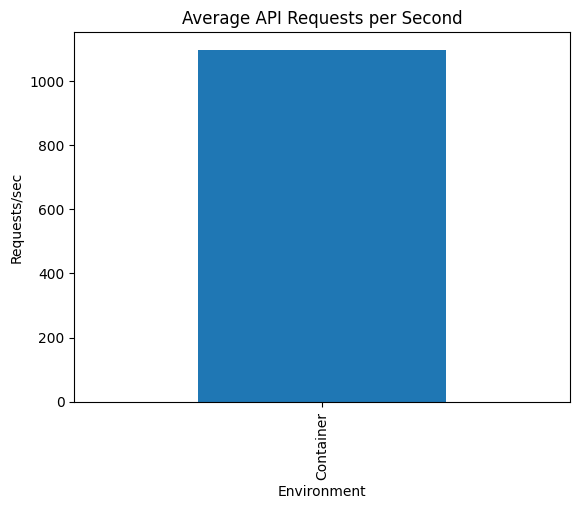

In [18]:
api.groupby("environment")["requests_per_sec"].mean().plot(
    kind="bar",
    title="Average API Requests per Second",
    ylabel="Requests/sec",
    xlabel="Environment"
)

In [19]:
network

,environment,throughput,unit
0,VM,2.73,Gbits/sec
1,Container,2.19,Gbits/sec


In [20]:
disk

,environment,workload,bandwidth,unit
0,vm,seq-read,887.0,MiB/s
1,vm,seq-write,1178.0,MiB/s
2,vm,random-read,20.7,MiB/s
3,vm,random-write,18.3,MiB/s
4,container,seq-read,811.0,MiB/s
5,container,seq-write,851.0,MiB/s
6,container,random-read,18.2,MiB/s
7,container,random-write,21.2,MiB/s


In [21]:
cpu_stats = pd.read_csv(
    "../results/processed/cpu_statistics.csv",
    index_col=0
)

cpu_stats

,mean,median,min,max,std
environment,,,,,
container,4020.613,4041.505,3868.77,4132.76,100.638815
vm,3731.717,3776.555,3040.91,4092.94,309.889471


In [22]:
memory_stats = pd.read_csv(
    "../results/processed/memory_statistics.csv",
    index_col=0
)

memory_stats

,mean,median,min,max,std
environment,,,,,
container,29520.900,29681.830,25556.91,31859.53,1790.080818
vm,42692.741,42694.365,41049.78,44014.45,821.149267


## Conclusion

The experimental results show that virtual machines and containers have different performance characteristics.

Containers generally provide lower startup overhead because they share the host operating system kernel. Virtual machines provide stronger isolation but introduce additional virtualization overhead.

CPU performance showed a difference between the two environments, while memory, disk and network performance varied depending on the workload.

The FastAPI benchmark was used to compare application-level performance under identical resource limits. Overall, the experiments demonstrate that containers are suitable when lightweight deployment and fast startup are important, whereas virtual machines are useful when stronger isolation and independent operating-system environments are required.